In [1]:
import demes
import numpy as np
import moments
import matplotlib.pyplot as plt
import msprime
import dpluspy

In [2]:
rs = np.logspace(-6, -2, 30)
u = 1e-8
b = demes.Builder()
b.add_deme("A", epochs=[{"start_size": 1e4, "end_time": 0}])
b.add_deme("B", start_time=2e4, ancestors=["A"], epochs=[{"start_size": 3e4, "end_time": 0}])
g = b.resolve()
y = moments.Demes.LD(g, ["A", "B"], r=rs, u=u)
print(y.names()[0])

['DD_0_0', 'DD_0_1', 'DD_1_1', 'Dz_0_0_0', 'Dz_0_0_1', 'Dz_0_1_1', 'Dz_1_0_0', 'Dz_1_0_1', 'Dz_1_1_1', 'pi2_0_0_0_0', 'pi2_0_0_0_1', 'pi2_0_0_1_1', 'pi2_0_1_0_1', 'pi2_0_1_1_1', 'pi2_1_1_1_1']


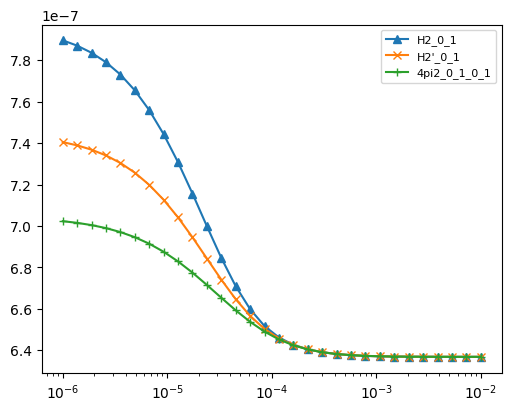

In [3]:
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
ax.plot(rs, y.H2(0, 1, phased=True), "-^", label="H2_0_1")
ax.plot(rs, y.H2(0, 1, phased=False), "-x", label="H2'_0_1")
ax.plot(rs, 4 * y.LD()[:, y.names()[0].index("pi2_0_1_0_1")], "-+", label="4pi2_0_1_0_1")
ax.legend()
ax.set_xscale("log")

In [63]:
nreps = 50
r = 1e-8
demog = msprime.Demography.from_demes(g)
tss = msprime.sim_ancestry(
    samples={"A": 1, "B": 1},
    demography=demog,
    num_replicates=nreps,
    sequence_length=1e7,
    recombination_rate=r
)
bins = np.logspace(-6, -2, 25)
stats = []
denom = None
for i, ts in enumerate(tss):
    mts = msprime.sim_mutations(ts, rate=u)
    if denom is None:
        get_denom = True
    else:
        get_denom = False
    raw = dpluspy.parsing.parse_stats(
        mts, 
        r=r, 
        r_bins=bins, 
        intervals=[(1, int(1e7) + 1, int(1e7) + 1)],
        get_denoms=get_denom
    )
    if get_denom:
        denom = raw[("None", 0)]["denoms"]
    numer = raw[("None", 0)]["sums"]
    stats.append(numer / denom[:, None])

[2026-03-20 13:29:51] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:52] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:53] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:53] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:54] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:55] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:56] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:56] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:57] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:58] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:59] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:29:59] Computed stats within chrom None interval 0 1-10000001
[2026-03-20 13:30:00] Computed stats within chrom None interval 0 1-10000001

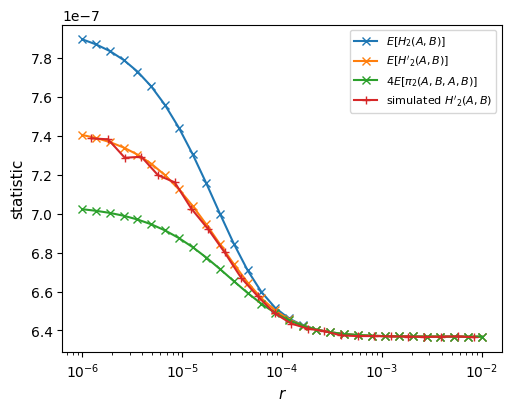

In [67]:
means = np.mean(stats, axis=0)
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
ax.plot(rs, y.H2(0, 1, phased=True), "-x", label="$E[H_2(A,B)]$")
ax.plot(rs, y.H2(0, 1, phased=False), "-x", label="$E[H'_2(A,B)]$")
ax.plot(rs, 4 * y.LD()[:, y.names()[0].index("pi2_0_1_0_1")], "-x", label=r"$4E[\pi_2(A,B,A,B)]$")
midbins = bins[:-1] + np.diff(bins) / 2
ax.plot(midbins, means[:-1, 1], "-+", label="simulated $H'_{2}(A,B)$")
ax.legend()
ax.set_xscale("log")
ax.set_xlabel("$r$")
ax.set_ylabel("statistic")
plt.savefig("figures/pi2_vs_unphased_H2.pdf")

In [39]:
rhos = np.logspace(-3, 3, 100)
u = 1e-8
Ne = 1e4
y = moments.LD.Demographics1D.snm(rho=rhos, theta=4 * Ne * u)
pi2 = y.LD()[:, y.names()[0].index("pi2_0_0_0_0")]
H = y.H()[0]

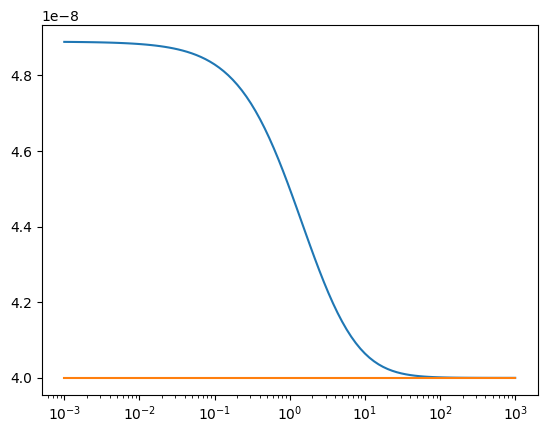

In [40]:
plt.plot(rhos, pi2)
plt.plot(rhos, [0.25 * H ** 2] * len(rhos))
plt.xscale("log")

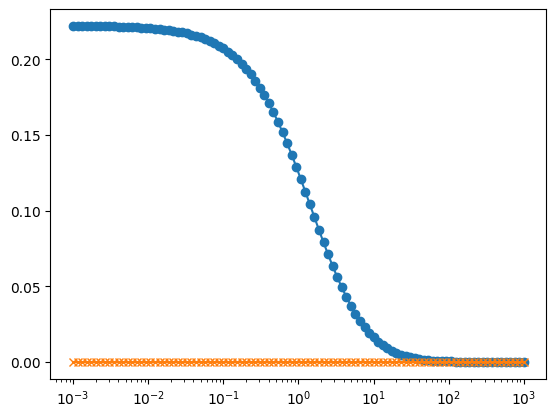

In [41]:
cov_Tij_Tkl = 4 / (18 + 13 * rhos + rhos ** 2)
plt.plot(rhos, cov_Tij_Tkl, "-o")
plt.plot(rhos, 4 * np.array(pi2 - (0.25 * H ** 2)), "-x")
plt.xscale("log")

In [ ]:
cov_Tij_Tkl = 4 / (18 + 13 * rhos + rhos ** 2)
my_pi2 = (4 * u * Ne) ** 2 / ((2 * 
plt.plot(rhos, pi2, "-x")
plt.xscale("log")